In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from processing import filter_region
from datetime import datetime

# load prediction arrays, create array objects

In [2]:
folder_path = 'predictions/8-27-2025/'

In [3]:
folders = [folder for folder in os.listdir(folder_path)]
print('len of folders: ', len(folders))

len of folders:  110


In [4]:
test_sum = np.load(f'{folder_path}image0/sum_arr_image0.npy')
print('test_sum shape: ', test_sum.shape)

test_sum shape:  (1, 100, 7493)


In [5]:
def load_arrs(arr_type: str):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [6]:
sum_arr = load_arrs('sum')
mean_arr = load_arrs('mean')
var_arr = load_arrs('var')
label_arr = load_arrs('label')

In [7]:
print(f'sum shape: {sum_arr.shape}; mean shape: {mean_arr.shape}; var shape: {var_arr.shape}')

sum shape: (110, 100, 7493); mean shape: (110, 7493); var shape: (110, 7493)


In [8]:
np.unique(mean_arr == var_arr, return_counts = True) # ensure we are returning different arrays

(array([False]), array([824230]))

# get mean and var arrays from V1
filtering done as well

In [9]:
mean_v1 = filter_region(1, label_arr, mean_arr)
var_v1 = filter_region(1, label_arr, var_arr)

In [10]:
print(f'mean shape: {mean_v1.shape}, var shape: {var_v1.shape}')

mean shape: (110, 5312), var shape: (110, 5312)


In [21]:
mean_masked = np.where(mean_v1 > 200, np.nan, mean_v1)

In [23]:
mean_masked

array([[ 4.48253631,  2.40415138,  2.1741385 , ...,  3.46549727,
         3.72360299,  1.8011298 ],
       [ 4.52462548,  2.3938452 ,  2.1200628 , ...,  3.44008887,
         3.69775857,  1.7945756 ],
       [ 4.51013305,  2.41961893,  2.14731242, ...,  3.4543789 ,
         3.6735942 ,  1.78208117],
       ...,
       [ 2.96683301,  4.93463582, 12.27066895, ...,  6.45803023,
        11.9888159 ,  5.52914932],
       [ 6.51205045,  1.45217201,  1.86029967, ...,  9.47522756,
        13.08551832,  2.78571205],
       [ 7.10266741,  1.52293653,  2.18051034, ...,  5.11882382,
         5.45417975,  2.99503925]])

In [24]:
var_masked = np.where(np.isnan(mean_masked), np.nan, var_v1)

In [25]:
var_masked

array([[0.08063027, 0.01644628, 0.02091719, ..., 0.02843449, 0.04020991,
        0.00977191],
       [0.07147933, 0.01843665, 0.02754832, ..., 0.03141268, 0.04010393,
        0.00822013],
       [0.08131231, 0.01864596, 0.02440153, ..., 0.02993036, 0.03761377,
        0.01028123],
       ...,
       [0.03619199, 0.06720968, 0.59309386, ..., 0.09813279, 0.5388874 ,
        0.12088601],
       [0.28648292, 0.00654168, 0.02622433, ..., 0.31492221, 0.57116872,
        0.03218335],
       [0.40654122, 0.00695528, 0.03502693, ..., 0.071912  , 0.10385039,
        0.03268105]])

In [26]:
print(f'# of mean nans: {np.isnan(mean_masked).sum()}; # of var nans: {np.isnan(var_masked).sum()}')

# of mean nans: 255; # of var nans: 255


# plots

In [37]:
neuron = 500
test_x = mean_masked[..., neuron]
test_y = var_masked[..., neuron]
print(test_x.shape)
print(test_y.shape)

(110,)
(110,)


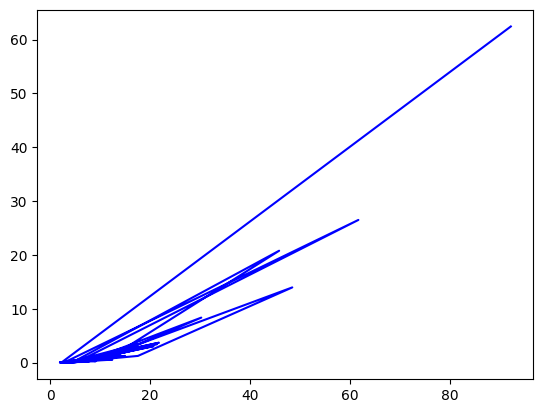

In [45]:
plt.plot(test_x[:10], test_y[:10], color = 'gray', linestyle = '--')
plt.plot(test_x[10:], test_y[10:], color = 'blue')
plt.show()

In [101]:
def lineplots_4x4(main_title, neurons, mean_masked, var_masked, savefig = False):

    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        ax.text(0.01, 0.99, f'neuron: {neuron}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'gray')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], alpha = 0.5, marker = '^')
        ax.plot(mean_masked[..., neuron], var_masked[..., neuron], color = 'red', alpha = 0.1)

        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

In [110]:
# get 16 random neurons here
neurons = np.random.randint(0, mean_v1.shape[1], 16)
neurons

array([   6, 1042, 1937, 2877, 3300, 2214, 4683, 4712, 4603, 2486, 2416,
       1953, 3497, 4497, 1815, 5216], dtype=int32)

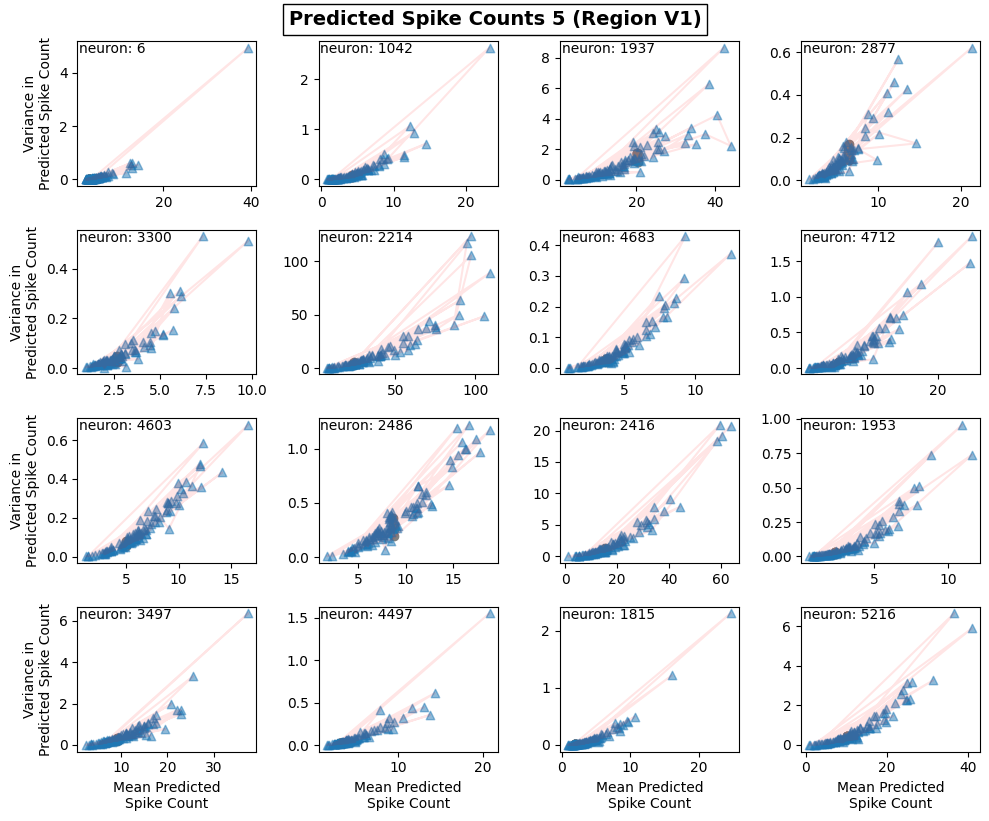

In [111]:
lineplots_4x4('Predicted Spike Counts 5 (Region V1)', neurons = neurons, mean_masked = mean_masked, var_masked = var_masked, savefig = True)